# Projeto de Ciência de Dados

## Objetivo

O objetivo deste projeto é analisar características biológicas de possums e desenvolver um modelo de machine learning capaz de prever a idade do animal com base em medidas corporais.

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.tree import DecisionTreeRegressor

# Carregamento do Dataset

Nesta etapa, o dataset é baixado utilizando o KaggleHub e carregado com Pandas.

In [2]:
path = kagglehub.dataset_download('abrambeyer/openintro-possum')

csv_path = os.path.join(path, 'possum.csv')

df = pd.read_csv(csv_path)

df.head()

100%|██████████| 2.15k/2.15k [00:00<00:00, 4.86MB/s]

Extracting files...


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


# Tratamento de Valores Faltantes

O dataset apresenta valores ausentes nas colunas `age` e `footlgth`.

Para evitar perda de dados, foi utilizada imputação pela média.

In [3]:
print(df.isnull().sum())

df['age'] = df['age'].fillna(df['age'].mean())
df['footlgth'] = df['footlgth'].fillna(df['footlgth'].mean())

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64


# Análise Exploratória

Nesta etapa são realizadas análises estatísticas e comparações entre sexo e população.

In [4]:
average_skull = np.mean(df['skullw'])

sex_comparision = df.groupby('sex').mean(numeric_only=True)

pop_comparision = df.groupby('Pop').mean(numeric_only=True)

print(average_skull)
print(sex_comparision)
print(pop_comparision)

56.88365384615384
          case      site       age    hdlngth     skullw   totlngth  \
sex                                                                   
f    43.418605  2.976744  3.976744  92.148837  56.588372  87.906977   
m    58.901639  4.081967  3.732240  92.922951  57.091803  86.511475   

         taill   footlgth   earconch        eye      chest      belly  
sex                                                                    
f    37.104651  69.096726  48.576744  14.811628  27.337209  32.883721  
m    36.942623  68.009836  47.816393  15.211475  26.762295  32.377049  
       case      site       age    hdlngth     skullw   totlngth      taill  \
Pop                                                                           
Vic    23.5  1.282609  4.014493  92.597826  56.654348  87.467391  35.934783   
other  75.5  5.482759  3.689655  92.606897  57.065517  86.787931  37.862069   

        footlgth   earconch        eye      chest      belly  
Pop                          

# Scatter Plot

O gráfico abaixo compara o comprimento total do corpo com a largura do crânio entre diferentes populações.

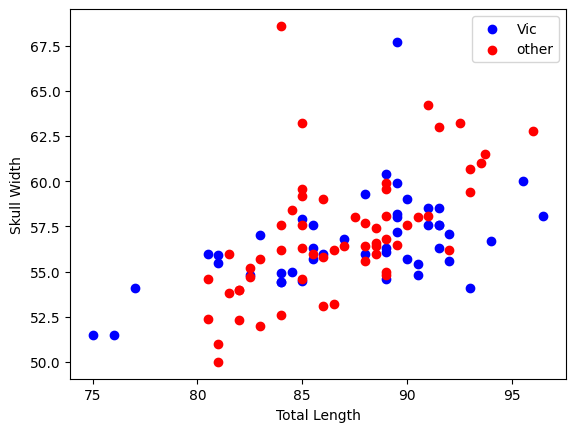

In [5]:
colors = {
    'Vic': 'blue',
    'other': 'red'
}

for pop in df['Pop'].unique():

    data = df[df['Pop'] == pop]

    plt.scatter(
        data['totlngth'],
        data['skullw'],
        label=pop,
        color=colors[pop]
    )

plt.xlabel('Total Length')
plt.ylabel('Skull Width')

plt.legend()

plt.show()

# Histograma

O histograma mostra a distribuição das idades dos possums no dataset.

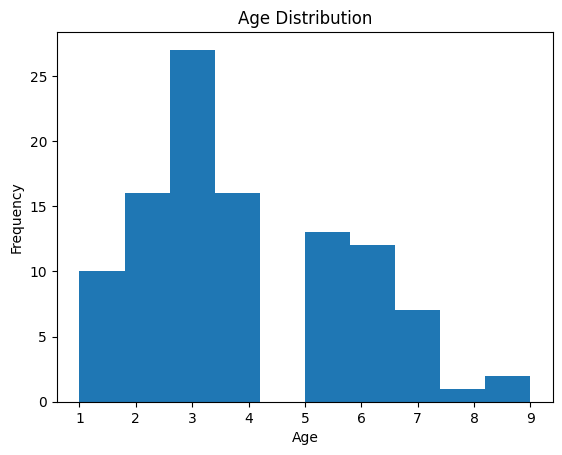

In [6]:
plt.hist(df['age'])

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

# Violin Plot

O violin plot permite visualizar a distribuição da largura do crânio entre machos e fêmeas.

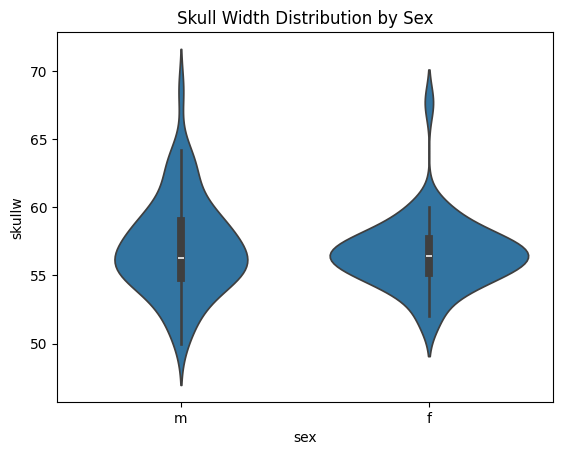

In [7]:
sb.violinplot(
    x='sex',
    y='skullw',
    data=df
)

plt.title('Skull Width Distribution by Sex')

plt.show()

# Machine Learning

Nesta etapa foi utilizado o modelo Decision Tree Regressor para prever a idade dos possums.

O modelo foi treinado utilizando características físicas dos animais, como comprimento do corpo, largura do crânio, tamanho da cabeça, cauda, pé e sexo.

Depois do treinamento, foi feita uma previsão utilizando os dados de um novo possum fictício.

In [8]:
df['sex'] = df['sex'].map({
    'm': 0,
    'f': 1
})

X = df[['totlngth', 'skullw', 'sex', 'hdlngth', 'taill', 'footlgth']]

Y = df['age']

model = DecisionTreeRegressor()

model.fit(X, Y)

DecisionTreeRegressor()

# Predição

O modelo será utilizado para prever a idade de um novo gambá fictício.

In [9]:
new_possum = pd.DataFrame([[
    90,
    58,
    0,
    95,
    36,
    75
]], columns=[
    'totlngth',
    'skullw',
    'sex',
    'hdlngth',
    'taill',
    'footlgth'
])

pred = model.predict(new_possum)

print('Idade prevista:', pred[0])

Idade prevista: 4.0


# Conclusão

O projeto permitiu analisar características biológicas dos possums por meio de análise exploratória de dados e gráficos.

Além disso, foi desenvolvido um modelo de machine learning capaz de prever a idade dos animais utilizando medidas corporais e sexo.

Com isso, o projeto demonstrou na prática conceitos importantes de ciência de dados, como tratamento de dados, visualização e modelagem preditiva.